# Exercise 1

We first load a dataset and examine its dimensions.

In [1]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import math
import numpy as np

xy_data = np.load('Ex1_polyreg_data.npy')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/Ex1_polyreg_data.npy'

np.shape(xy_data)

(70, 2)

The matrix `xy_data` contains $70$ rows, each a data point of the form $(x_i,y_i)$ for $i=1, \ldots, 70$.

### 1a) Plot the data in a scatterplot.

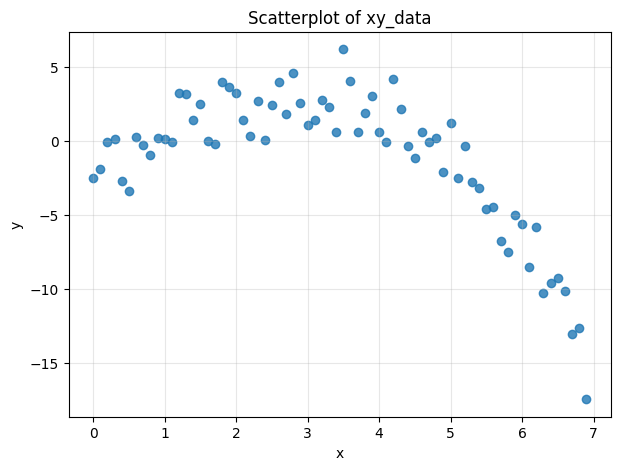

In [ ]:
import matplotlib.pyplot as plt

x = xy_data[:, 0]
y = xy_data[:, 1]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='tab:blue', alpha=0.8)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatterplot')
plt.grid(alpha=0.3)
plt.show()



### 1b) Write a function `polyreg` to fit a polynomial of a given order to a dataset. 
The inputs to the function are a data matrix of dimension $N \times 2$,  and $k \geq 0$, the order of the polynomial.   The function should compute the coefficients of the polynomial $\beta_0 + \beta_1 x +  \ldots  +\beta_k x^{k}$ via least squares regression, and should return the coefficient vector, the fit, and the vector of residuals. 

If specified the degree $k$ is greater than or equal to $N$, then the function must fit an order $(N-1)$ polynomial and set the remaining coefficients to zero.

**NOTE**: You are *not* allowed to use the built-in function `np.polyfit`.

In [ ]:
def polyreg(data_matrix, k):
    data_matrix = np.asarray(data_matrix)

    if data_matrix.ndim != 2 or data_matrix.shape[1] != 2:
        raise ValueError("data_matrix must be an N x 2 array")
    if k < 0:
        raise ValueError("k must be non-negative")

    N = data_matrix.shape[0]
    x = data_matrix[:, 0]
    y = data_matrix[:, 1]

    # If k >= N, fit degree N-1 and pad remaining coefficients with zeros
    k_eff = min(k, N - 1)

    # Create matrix X with columns [1, x, x^2, ..., x^k_eff]
    feature_cols = [np.ones(N)]
    for p in range(1, k_eff + 1):
        feature_cols.append(x**p)
    X = np.column_stack(feature_cols)

    # Compute beta* using least squares formula as in Notebook 1
    beta_eff = np.linalg.lstsq(X, y, rcond=None)[0]

    # Pad coefficient vector to requested length (k+1)
    beta = np.zeros(k + 1)
    beta[:k_eff + 1] = beta_eff

    fit = X.dot(beta_eff)
    residuals = y - fit

    return beta, fit, residuals


Use the tests below to check the outputs of the function you have written:

In [4]:
# Some tests to make sure your function is working correctly

xcol = np.arange(-1, 1.05, 0.1)
ycol = 2 - 7*xcol + 3*(xcol**2)  # We are generating data accoridng to y = 2 - 7x + 3x^2
test_matrix = np.transpose(np.vstack((xcol,ycol)))
test_matrix.shape

beta_test = polyreg(test_matrix, k=2)[0] 
assert((np.round(beta_test[0], 3) == 2) and (np.round(beta_test[1], 3) == -7) and (np.round(beta_test[2], 3) == 3))  
# We want to check that using the function with k=2 recovers the coefficients exactly

# Now check the zeroth order fit, i.e., the function gives the correct output with k=0
beta_test = polyreg(test_matrix, k=0)[0]
res_test = polyreg(test_matrix, k=0)[2] #the last output of the function gives the vector of residuals

assert(np.round(beta_test, 3) == 3.1)
assert(np.round(np.linalg.norm(res_test), 3) == 19.937)

### 1c) Use `polyreg` to fit polynomial models for the data in `xy_data` for $k=2,3,4$:

- Plot the fits for the three cases on the same plot together with the scatterplot of the data. The plots should be labelled and a legend included. 
- Compute and print the SSE and $R^2$ coefficient for each of the three cases.
- Which of the three models you would choose? Briefly justify your choice.

In [ ]:
#Your code here



 #### State which model you choose and briefly justify your choice.
 
 
 < fill in your answer in this cell.>
 
 

### 1d)  For the model you have chosen in the previous part (either $k=2/3/4)$:

- Plot the residuals in a scatter plot. 
- Plot a histogram of the residuals along with a Gaussian pdf with zero mean and the same standard deviation as the residuals.

In [ ]:
#Your code here

